# Demo 10 — Heston pricing and implied-vol smile

This notebook follows the same **demo style** as the rest of the repo and now uses the **trusted strike-vectorized Heston pricer directly**.

What it demonstrates:

- price a **single-maturity Heston call/put slice** with array-valued strikes
- recover **Black-76 implied vols** from the vectorized call-price slice
- summarize the scenario and parameter set in compact tables
- validate the slice with **put–call parity**, **non-negativity**, **monotonicity**, and a lightweight **vectorization contract check**

> Tip: if you are running this notebook from the repository rather than an installed package, the next cell tries to add `src/` to `sys.path` automatically.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root() -> Path | None:
    starts: list[Path] = [Path.cwd()]
    mnt_data = Path("/mnt/data")
    if mnt_data.exists():
        starts.extend([mnt_data, mnt_data / "repo_unzipped"])

    seen: set[Path] = set()
    for start in starts:
        for candidate in (start, *start.parents):
            if candidate in seen:
                continue
            seen.add(candidate)
            if (candidate / "src" / "option_pricing").exists():
                return candidate
            for child_name in ("option-pricing-library",):
                child = candidate / child_name
                if (child / "src" / "option_pricing").exists():
                    return child
    return None


ROOT = _find_repo_root()
if ROOT is not None:
    SRC = ROOT / "src"
    if str(SRC) not in sys.path:
        sys.path.insert(0, str(SRC))

PROFILE = "quick"  # switch to "full" for a denser strike grid


## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from option_pricing.models.heston import HestonParams
from option_pricing.pricers.heston import (
    heston_price_call_from_ctx,
    heston_price_put_from_ctx,
)
from option_pricing.types import MarketData
from option_pricing.vol.implied_vol_slice import implied_vol_black76_slice

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


def build_smile_frame(
    *,
    strikes: np.ndarray,
    call_prices: np.ndarray,
    put_prices: np.ndarray,
    implied_vols: np.ndarray,
    forward: float,
) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "strike": np.asarray(strikes, dtype=float),
            "log_moneyness": np.log(np.asarray(strikes, dtype=float) / float(forward)),
            "call_price": np.asarray(call_prices, dtype=float),
            "put_price": np.asarray(put_prices, dtype=float),
            "implied_vol": np.asarray(implied_vols, dtype=float),
        }
    )


def validation_summary(
    *,
    smile: pd.DataFrame,
    forward: float,
    df: float,
    strikes: np.ndarray,
    call_prices: np.ndarray,
    put_prices: np.ndarray,
    vectorized_call_prices: np.ndarray,
    vectorized_put_prices: np.ndarray,
) -> pd.DataFrame:
    parity_err = float(
        np.max(
            np.abs(
                (smile["call_price"] - smile["put_price"]).to_numpy()
                - float(df) * (float(forward) - smile["strike"].to_numpy())
            )
        )
    )
    call_monotone = bool(np.all(np.diff(smile["call_price"].to_numpy()) <= 1e-8))
    prices_nonnegative = bool(np.all(smile["call_price"].to_numpy() >= -1e-12))
    put_prices_nonnegative = bool(np.all(smile["put_price"].to_numpy() >= -1e-12))
    vectorized_call_shape_ok = bool(
        isinstance(vectorized_call_prices, np.ndarray)
        and vectorized_call_prices.shape == strikes.shape
    )
    vectorized_put_shape_ok = bool(
        isinstance(vectorized_put_prices, np.ndarray)
        and vectorized_put_prices.shape == strikes.shape
    )
    all_finite = bool(
        np.all(np.isfinite(call_prices))
        and np.all(np.isfinite(put_prices))
        and np.all(np.isfinite(smile["implied_vol"].to_numpy()))
    )

    checks = pd.DataFrame(
        [
            {
                "check": "put-call parity residual",
                "value": parity_err,
                "target": "<= 1e-8",
                "pass": parity_err <= 1e-8,
            },
            {
                "check": "call prices decreasing in strike",
                "value": call_monotone,
                "target": "True",
                "pass": call_monotone,
            },
            {
                "check": "call prices nonnegative",
                "value": prices_nonnegative,
                "target": "True",
                "pass": prices_nonnegative,
            },
            {
                "check": "put prices nonnegative",
                "value": put_prices_nonnegative,
                "target": "True",
                "pass": put_prices_nonnegative,
            },
            {
                "check": "vectorized call output shape matches strike grid",
                "value": vectorized_call_shape_ok,
                "target": "True",
                "pass": vectorized_call_shape_ok,
            },
            {
                "check": "vectorized put output shape matches strike grid",
                "value": vectorized_put_shape_ok,
                "target": "True",
                "pass": vectorized_put_shape_ok,
            },
            {
                "check": "all outputs finite",
                "value": all_finite,
                "target": "True",
                "pass": all_finite,
            },
        ]
    )
    return checks


def vectorization_contract_table(
    *,
    strikes: np.ndarray,
    subset_idx: np.ndarray,
    ctx,
    tau: float,
    params: HestonParams,
    vectorized_call_prices: np.ndarray,
    vectorized_put_prices: np.ndarray,
) -> pd.DataFrame:
    subset_strikes = np.asarray(strikes[subset_idx], dtype=float)

    scalar_call_prices = np.array(
        [
            float(
                heston_price_call_from_ctx(
                    strike=float(k),
                    ctx=ctx,
                    tau=tau,
                    params=params,
                )
            )
            for k in subset_strikes
        ],
        dtype=float,
    )
    scalar_put_prices = np.array(
        [
            float(
                heston_price_put_from_ctx(
                    strike=float(k),
                    ctx=ctx,
                    tau=tau,
                    params=params,
                )
            )
            for k in subset_strikes
        ],
        dtype=float,
    )

    out = pd.DataFrame(
        {
            "strike": subset_strikes,
            "call_vectorized": vectorized_call_prices[subset_idx],
            "call_scalar": scalar_call_prices,
            "call_abs_error": np.abs(vectorized_call_prices[subset_idx] - scalar_call_prices),
            "put_vectorized": vectorized_put_prices[subset_idx],
            "put_scalar": scalar_put_prices,
            "put_abs_error": np.abs(vectorized_put_prices[subset_idx] - scalar_put_prices),
        }
    )
    return out


## 1) Define the pricing scenario

We keep the first Heston demo intentionally compact:

- one market environment
- one maturity
- one Heston parameter set
- a strike grid wide enough to show skew / smile behavior

`PROFILE = "quick"` uses a compact grid for faster iteration.  
Switch to `"full"` for a denser smile.


In [3]:
market = MarketData(spot=100.0, rate=0.02, dividend_yield=0.00)
ctx = market.to_context()
tau = 1.0

params = HestonParams(
    kappa=2.0,   # mean reversion speed
    vbar=0.04,   # long-run variance
    eta=0.55,    # vol of vol
    rho=-0.70,   # spot/variance correlation
    v=0.05,      # initial variance
)

if PROFILE == "full":
    strikes = np.linspace(60.0, 140.0, 41)
else:
    strikes = np.linspace(70.0, 130.0, 25)

forward = float(ctx.fwd(tau))
df = float(ctx.df(tau))

scenario = pd.DataFrame(
    [
        {
            "profile": PROFILE,
            "spot": market.spot,
            "rate": market.rate,
            "dividend_yield": market.dividend_yield,
            "tau": tau,
            "forward": forward,
            "discount_factor": df,
            "n_strikes": len(strikes),
            "strike_min": float(np.min(strikes)),
            "strike_max": float(np.max(strikes)),
        }
    ]
)

param_table = pd.DataFrame(
    [
        {
            "kappa": params.kappa,
            "vbar": params.vbar,
            "eta": params.eta,
            "rho": params.rho,
            "v": params.v,
        }
    ]
)

display(scenario)
display(param_table)


,profile,spot,rate,dividend_yield,tau,forward,discount_factor,n_strikes,strike_min,strike_max
0,quick,100.000000,0.020000,0.000000,1.000000,102.020134,0.980199,25,70.000000,130.000000


,kappa,vbar,eta,rho,v
0,2.000000,0.040000,0.550000,-0.700000,0.050000


## 2) Price the strike slice with the trusted vectorized API

The Heston pricer now accepts an **array of strikes** directly, so the notebook uses the vectorized API without any fallback wrapper.


In [4]:
call_prices = np.asarray(
    heston_price_call_from_ctx(
        strike=strikes,
        ctx=ctx,
        tau=tau,
        params=params,
    ),
    dtype=float,
)
put_prices = np.asarray(
    heston_price_put_from_ctx(
        strike=strikes,
        ctx=ctx,
        tau=tau,
        params=params,
    ),
    dtype=float,
)

implied_vols = implied_vol_black76_slice(
    forward=forward,
    strikes=strikes,
    tau=tau,
    df=df,
    prices=call_prices,
    is_call=True,
)

smile = build_smile_frame(
    strikes=strikes,
    call_prices=call_prices,
    put_prices=put_prices,
    implied_vols=implied_vols,
    forward=forward,
)

run_summary = pd.DataFrame(
    [
        {"quantity": "pricing mode", "value": "direct vectorized strike slice"},
        {"quantity": "call output type", "value": type(call_prices).__name__},
        {"quantity": "put output type", "value": type(put_prices).__name__},
        {"quantity": "call output shape", "value": str(call_prices.shape)},
        {"quantity": "put output shape", "value": str(put_prices.shape)},
        {"quantity": "min implied vol", "value": float(np.min(implied_vols))},
        {"quantity": "max implied vol", "value": float(np.max(implied_vols))},
    ]
)

display(run_summary)
display(smile.head(10))


,quantity,value
0,pricing mode,direct vectorized strike slice
1,call output type,ndarray
2,put output type,ndarray
3,call output shape,"(25,)"
4,put output shape,"(25,)"
5,min implied vol,0.145874
6,max implied vol,0.272446


,strike,log_moneyness,call_price,put_price,implied_vol
0,70.000000,-0.376675,32.240291,0.854198,0.272446
1,72.500000,-0.341584,29.977214,1.041617,0.265467
2,75.000000,-0.307682,27.747325,1.262226,0.258549
3,77.500000,-0.274892,25.555345,1.520742,0.251686
4,80.000000,-0.243144,23.406553,1.822447,0.244876
5,82.500000,-0.212372,21.306849,2.173240,0.238116
6,85.000000,-0.182519,19.262809,2.579697,0.231407
7,87.500000,-0.153531,17.281739,3.049123,0.224752
8,90.000000,-0.125361,15.371713,3.589594,0.218159
9,92.500000,-0.097962,13.541582,4.209959,0.211636


## 3) Plot the implied-vol smile

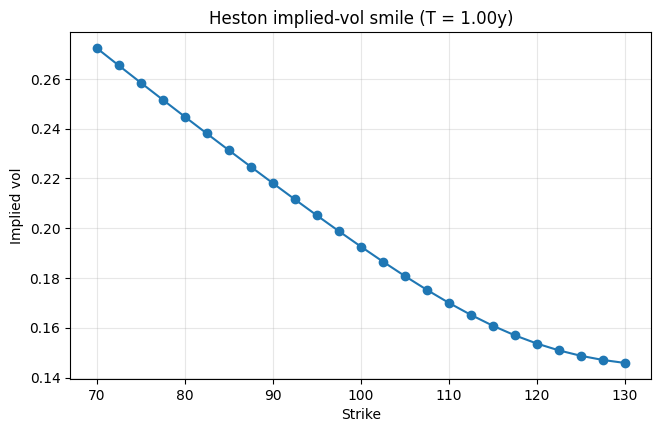

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(smile["strike"], smile["implied_vol"], marker="o")
ax.set_title(f"Heston implied-vol smile (T = {tau:.2f}y)")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol")
ax.grid(True, alpha=0.3)
plt.show()


## 4) Inspect the price slice

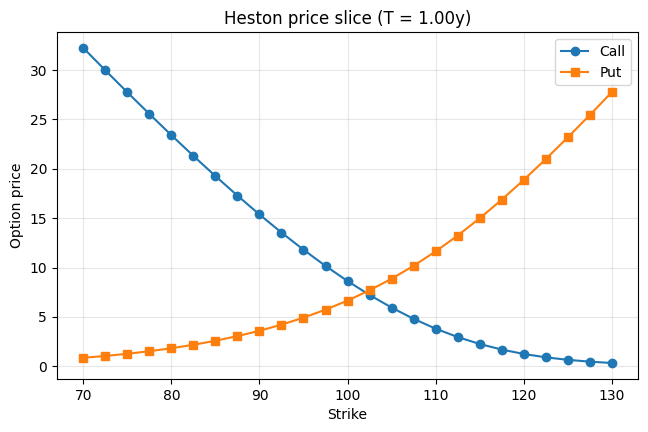

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(smile["strike"], smile["call_price"], marker="o", label="Call")
ax.plot(smile["strike"], smile["put_price"], marker="s", label="Put")
ax.set_title(f"Heston price slice (T = {tau:.2f}y)")
ax.set_xlabel("Strike")
ax.set_ylabel("Option price")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


## 5) Lightweight vectorization contract check

The demo prices a small subset twice:

- once through the **vectorized strike-slice call**
- once through the **scalar one-strike call**

This is not a fallback path; it is just a compact sanity check that the array API agrees with the scalar API on representative strikes.


In [7]:
subset_idx = np.array([0, len(strikes) // 4, len(strikes) // 2, 3 * len(strikes) // 4, len(strikes) - 1])
contract = vectorization_contract_table(
    strikes=strikes,
    subset_idx=subset_idx,
    ctx=ctx,
    tau=tau,
    params=params,
    vectorized_call_prices=call_prices,
    vectorized_put_prices=put_prices,
)
display(contract)

print("max call abs error on subset:", float(contract["call_abs_error"].max()))
print("max put abs error on subset:", float(contract["put_abs_error"].max()))


,strike,call_vectorized,call_scalar,call_abs_error,put_vectorized,put_scalar,put_abs_error
0,70.000000,32.240291,32.240291,0.000000,0.854198,0.854198,0.000000
1,85.000000,19.262809,19.262809,0.000000,2.579697,2.579697,0.000000
2,100.000000,8.629359,8.629359,0.000000,6.649227,6.649227,0.000000
3,115.000000,2.256230,2.256230,0.000000,14.979077,14.979077,0.000000
4,130.000000,0.329935,0.329935,0.000000,27.755762,27.755762,0.000000


max call abs error on subset: 0.0
max put abs error on subset: 0.0


## 6) Validation checks

These are the minimum sanity checks you would want before using the smile downstream in calibration or comparison work.


In [8]:
checks = validation_summary(
    smile=smile,
    forward=forward,
    df=df,
    strikes=strikes,
    call_prices=call_prices,
    put_prices=put_prices,
    vectorized_call_prices=call_prices,
    vectorized_put_prices=put_prices,
)
display(checks)

assert isinstance(call_prices, np.ndarray)
assert isinstance(put_prices, np.ndarray)
assert call_prices.shape == strikes.shape
assert put_prices.shape == strikes.shape
assert np.all(np.isfinite(implied_vols))
assert float(contract["call_abs_error"].max()) <= 1e-10
assert float(contract["put_abs_error"].max()) <= 1e-10
assert bool(checks["pass"].all())


,check,value,target,pass
0,put-call parity residual,0.000000,<= 1e-8,True
1,call prices decreasing in strike,True,True,True
2,call prices nonnegative,True,True,True
3,put prices nonnegative,True,True,True
4,vectorized call output shape matches strike grid,True,True,True
5,vectorized put output shape matches strike grid,True,True,True
6,all outputs finite,True,True,True


## Takeaways

- The notebook now uses the **trusted vectorized Heston strike API directly**.
- The structure matches the rest of the repo's demos more closely: title block, `src/` bootstrap, numbered sections, compact summary tables, plots, and explicit validation.
- The extra scalar comparison is now only a **contract check**, not a compatibility workaround.
